In [2]:
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages

C:\code\langgraph-learning\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [3]:
from dotenv import load_dotenv

load_dotenv()

True

In [24]:
from langchain.chat_models import init_chat_model

llm = init_chat_model("google_genai:gemini-flash-latest")


In [25]:
response = llm.invoke("Who is the first person to land on Moon?")
print(response)

content=[{'type': 'text', 'text': 'The first person to land on the Moon was **Neil Armstrong**.\n\nHe stepped onto the lunar surface on **July 20, 1969**, as part of NASA\'s **Apollo 11** mission. Upon stepping onto the surface, he famously said: *"That\'s one small step for [a] man, one giant leap for mankind."*\n\nHe was followed shortly after by **Buzz Aldrin**, while their teammate **Michael Collins** remained in orbit around the Moon in the command module.', 'extras': {'signature': 'EvwECvkEAb4+9vsqOPk7DXekEIHHTWlOheuWDEVePFRRbF5TtkcoAwqTM1fb3jN342OjYBKPlsr94FX7rP6BCPuLlfamAZEGkjwcCYWpnJb/PAHe8CKjHjxjQmRUdQMrru7YD1hVmeuK6tkZN92SQj3vzxUgZxnazpb9Y2ZT7c6US4GP4KoVd8v5A2xWHZmQ0vHwZgMMlP1WGl8oiT33TJ76cps6yJfhloRMnolMdkJ98IU89ZwqvxWcDxwxCw9C+rBJt6jkWA5I8lvByBVDIELKOj/rA9NNIV7lekbkfV1VRgmcOdApLidy/UOWPv/Mm7c6WLEX9VfvQd6ZLOqAEujNVdV0DFUqiyyvwYxQi5WNibKAydoKwGCo+OFkB8Z+c//iB93AMM6ebWTOdMNIqfx+nHkXDh7vPuEERF3Ka67bHQ7Bw3XuUypbwxx6nJSansdnz8G5oN3gdz5krnYPk6F4beuJv2jmb7qqZh0jyaPzJg2i1apC2bNK89q

In [6]:
class State(TypedDict) :
    messages: Annotated[list,add_messages]

In [7]:
def chatbot(state: State) -> State :
    return {"messages":[llm.invoke(state["messages"])]}

In [8]:
from langgraph.graph import StateGraph,START,END

builder = StateGraph(State)

builder.add_node("chatbot_node",chatbot)
builder.add_edge(START, "chatbot_node")
builder.add_edge("chatbot_node",END)




In [9]:
graph = builder.compile()

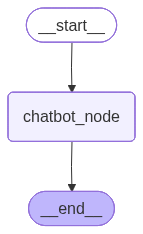

In [10]:
from IPython.display import Image,display

display(graph)

In [11]:
message = {"role":"user","content" : "Who walked on the Moon first? Print only the name"}

response = graph.invoke({"messages":[message]})

response["messages"]

[HumanMessage(content='Who walked on the Moon first? Print only the name', additional_kwargs={}, response_metadata={}, id='2fd07692-4ed2-45b6-9e5e-c2578c1837da'),
 AIMessage(content='Neil Armstrong', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d2fd1-688f-7f50-8536-5cfe24eab890-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 45, 'total_tokens': 57, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 43}})]

In [26]:
#message = {"role":"user","content" : "Who is the prime minister of Sri Lanka in 2025?"}
message = {"role":"user","content" : "Who is the current prime minister of Sri Lanka?"}

response = graph.invoke({"messages":[message]})

response["messages"]

[HumanMessage(content='Who is the current prime minister of Sri Lanka?', additional_kwargs={}, response_metadata={}, id='36e15032-1acb-45c7-a858-444bcf05e34e'),
 AIMessage(content=[{'type': 'text', 'text': 'The current Prime Minister of Sri Lanka is **Harini Amarasuriya**. \n\nShe was sworn in on September 24, 2024, by President Anura Kumara Dissanayake. She is the first woman to hold the office in 24 years.', 'extras': {'signature': 'Er4GCrsGAb4+9vvb8gMszBMnMKUAzbRwX9ORXGlI9Mgnxymi+X5cpQcbTXwVv7njh9mPep/HFHmA4Vi3DuJ/wrTBd2TNcF62MI+NZa8ouJ+YYp42Js2DBdzTqxiSQDu8tiFHsSXarKyK8wr4sO+oMJegJi1u/Eu6Dro1aF9SvAKFLnek2TG5ELhkd0X/rRP1i8tV84LGGamepqaDFZPNzHRvO79TiodhfZJs7349/4khCkPKBrMh7wrPBLqaNPhaDwOpj4E8qvV55P48+7AJ7FZwU3jlNH137Sw4wC0mMfRznPCDK4qiw0se8voFMyvA6/RmqtClpP6Uv8o33ixCSwkX7OvbyuNV26JCWF6+Px0A3hgiQ9+/CzNyPPmogk5L0GX5Glf9XjRKEwThczAZiR4sN9ttCpmQjXn8nnXPBWYWNFQx9/P+esboz2E7J7CLbvowsUZAe/jSqBPoz8ha4nFMskHLYDVJU+p63QbM5mbtLGcEe1E+pk98Ix1JylXHOz2Nx0Kp0l5QRWUqUXE3Hsc46XkQectm/ZrEYJSrjnoE9vPoU